In [17]:
# базовые
from datetime import datetime
import os

# библиотеки ML
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    max_error,
    accuracy_score
)


# работа с данными
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.dates as mdates
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# архитектура
from pinn_architecture import PINN_Mill

In [2]:
test = pd.read_csv('test_data_not_shuffled.csv')
periodic = pd.read_csv('periodic_selections.csv')

In [3]:
model_ann = PINN_Mill()
state_dict = torch.load('best_ann_2026-06-07_11.pt', weights_only=True)
model_ann.load_state_dict(state_dict)
model_ann.eval()

model_pinn = PINN_Mill()
state_dict = torch.load('best_pinn_2026-06-07_20.pt', weights_only=True)
model_pinn.load_state_dict(state_dict)
model_pinn.eval()

PINN_Mill(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [4]:
t_real_test = torch.Tensor(test['t'].values).unsqueeze(1)
z_real_test = torch.Tensor(test['z'].values).unsqueeze(1)
Fm_real_test = torch.Tensor(test['Fm'].values).unsqueeze(1)
Fl_real_test = torch.Tensor(test['Fl'].values).unsqueeze(1)
S_real_test = torch.Tensor(test['S'].values).unsqueeze(1)
S_periodic = torch.Tensor(periodic[periodic['average_time'].isin(test['date'])]["S_[m2/kg]"].values).unsqueeze(1)

/var/folders/pw/9v35zrks1gj89m9hgtttxv1c0000gn/T/ipykernel_80406/716235324.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  t_real_test = torch.Tensor(test['t'].values).unsqueeze(1)


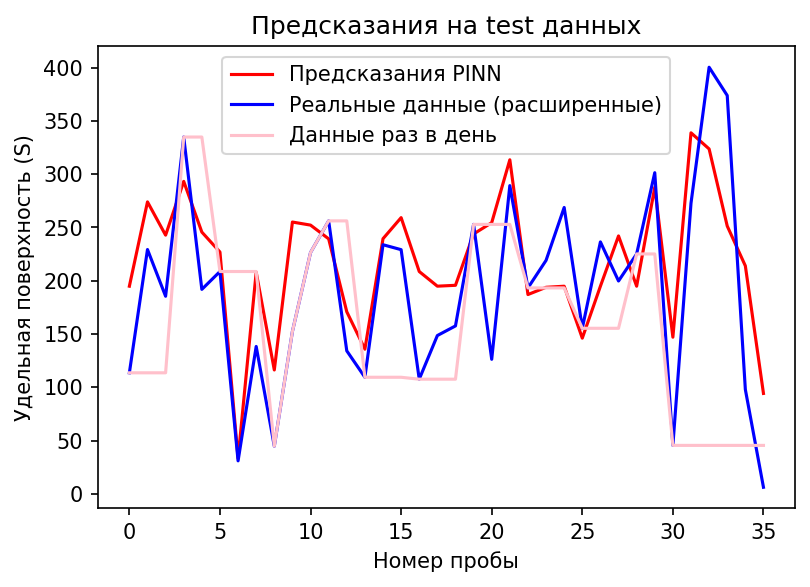

In [32]:
plt.figure(figsize=(6, 4), dpi=150)
_, preds_pinn = model_pinn(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
_, preds_ann = model_ann(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
plt.plot(preds_pinn.detach().numpy(), c='red', label='Предсказания PINN')
plt.plot(S_real_test, label='Реальные данные (расширенные)', c='b')
plt.plot(S_periodic, label='Данные раз в день', c='pink')
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# plt.axhline(250, linestyle=':', c='lightgrey')

# plt.axhline(150, linestyle=':', c='lightgrey')
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

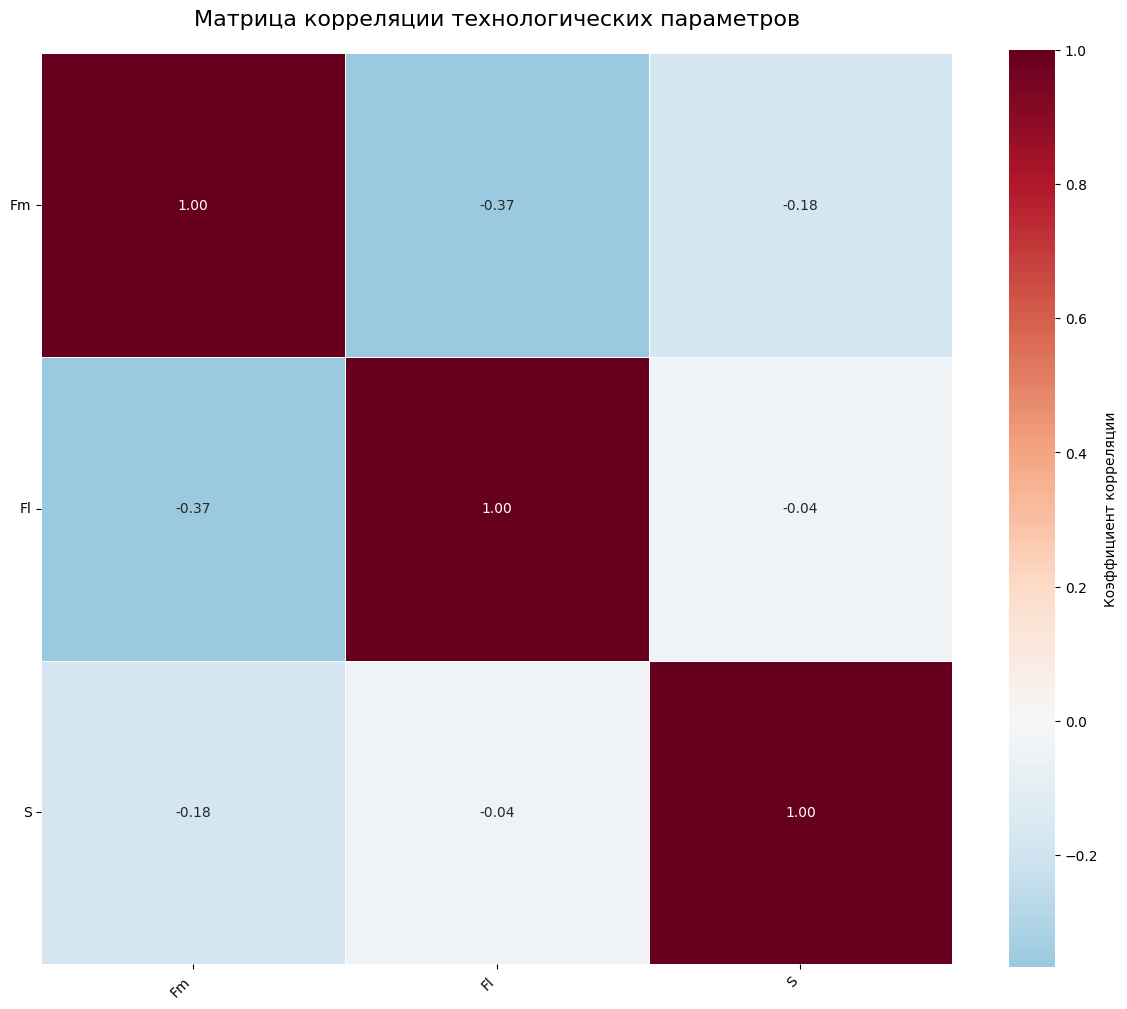

In [128]:
features = [
    "Fm",
    "Fl",
    "S"
]

corr = test[features].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Коэффициент корреляции"}
)

plt.title(
    "Матрица корреляции технологических параметров",
    fontsize=16,
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# confusion matrix

In [7]:
LOW = 150
HIGH = 250

In [8]:
# расширенный
real_out = (S_real_test < LOW) | (S_real_test > HIGH)
n_real_out = real_out.sum()
n_real_in = (~real_out).sum()
print(f'Выходов за пределы: {n_real_out}')
print(f'В пределах нормы: {n_real_in}')
print('-'*30)

# пинн
pinn_out = (preds_pinn < LOW) | (preds_pinn > HIGH)
n_pinn_out = pinn_out.sum()
n_pinn_in = (~pinn_out).sum()
print(f'PINN считает выходов: {n_pinn_out}')
print(f'В пределах нормы: {n_pinn_in}')
print('-'*30)

# обычный
usual_out = (S_periodic < LOW) | (S_periodic > HIGH)
n_usual_out = usual_out.sum()
n_usual_in = (~usual_out).sum()
print(f'Выходов за пределы при обычном отборе: {n_usual_out}')
print(f'В пределах нормы: {n_usual_in}')
print('-'*30)

Выходов за пределы: 21
В пределах нормы: 15
------------------------------
PINN считает выходов: 17
В пределах нормы: 19
------------------------------
Выходов за пределы при обычном отборе: 23
В пределах нормы: 13
------------------------------


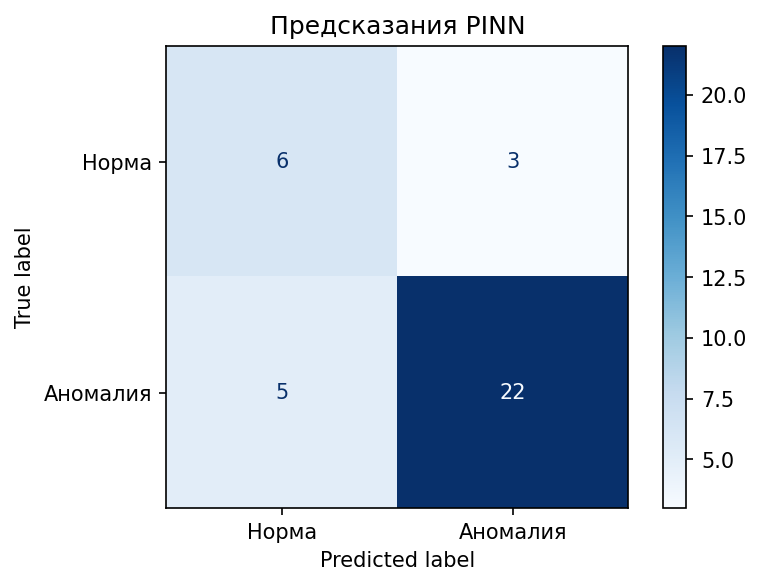

In [137]:
class_names = ['Норма', 'Аномалия']
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)  # задаём dpi через subplots
ConfusionMatrixDisplay.from_predictions(
    real_out.detach().numpy().astype(int),
    pinn_out.detach().numpy().astype(int),
    display_labels=class_names,
    cmap="Blues",
    ax=ax  # передаём оси
)
plt.title('Предсказания PINN')
plt.show()

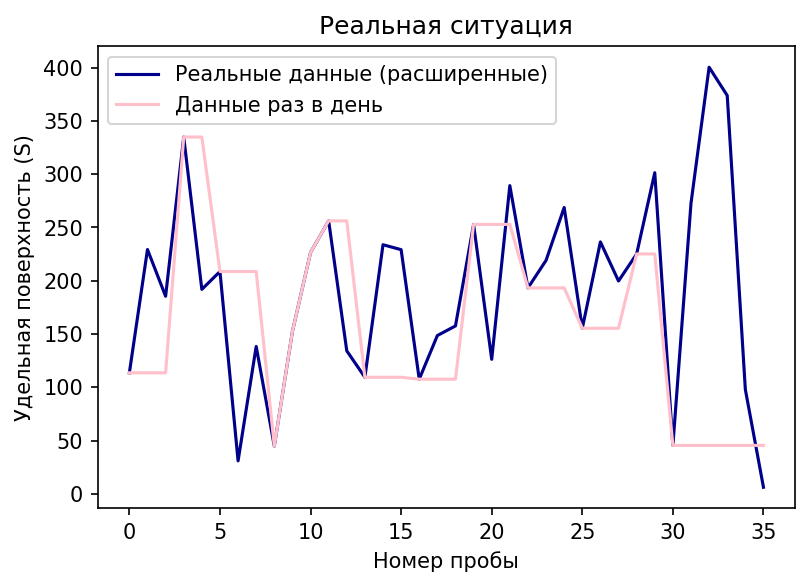

In [31]:
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(S_real_test, label='Реальные данные (расширенные)', c='darkblue',)
plt.plot(S_periodic, label='Данные раз в день', c='pink', )
plt.title("Реальная ситуация")
plt.ylabel("Удельная поверхность (S)")
ax = plt.gca()
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))  # или '%b %d' для 'May 15'
# plt.axhline(250, linestyle=':', c='lightgrey')

# plt.axhline(150, linestyle=':', c='lightgrey')
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

In [14]:
# Преобразуем тензоры PyTorch в массивы NumPy
y_true = real_out.detach().numpy().astype(int)
y_pred = pinn_out.detach().numpy().astype(int)

# Расчёт метрик
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

# Вывод результатов
print('Метрики классификации для PINN')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')
print('Confusion matrix:')
print(conf_matrix)

Метрики классификации для PINN
Accuracy:  0.6111
Precision: 0.7059
Recall:    0.5714
F1-score:  0.6316
Confusion matrix:
[[10  5]
 [ 9 12]]


In [15]:
# Преобразуем тензоры PyTorch в массивы NumPy
y_true = real_out.detach().numpy().astype(int)
y_pred = usual_out.detach().numpy().astype(int)

# Расчёт метрик
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

# Вывод результатов
print('Метрики классификации для одного измерения за день')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')
print('Confusion matrix:')
print(conf_matrix)

Метрики классификации для одного измерения за день
Accuracy:  0.7222
Precision: 0.7391
Recall:    0.8095
F1-score:  0.7727
Confusion matrix:
[[ 9  6]
 [ 4 17]]


In [ ]:
preds_pinn.detach().numpy()
S_real_test
S_periodic

In [25]:
y_true = S_real_test.numpy().flatten()
y_pred = preds_pinn.detach().numpy().flatten()
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print('Метрики моделирования PINN')
print(f'MAE  = {mae:.4f}')
print(f'MSE  = {mse:.4f}')
print(f'RMSE = {rmse:.4f}')

Метрики моделирования PINN
MAE  = 51.2421
MSE  = 3883.2979
RMSE = 62.3161


In [27]:
y_true = S_real_test.numpy().flatten()
y_pred = S_periodic.numpy().flatten()
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print('Метрики реального ТП')
print(f'MAE  = {mae:.4f}')
print(f'MSE  = {mse:.4f}')
print(f'RMSE = {rmse:.4f}')

Метрики реального ТП
MAE  = 69.5503
MSE  = 12559.0195
RMSE = 112.0670


In [28]:
import time

In [29]:
start = time.perf_counter()
pred = model_pinn(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
end = time.perf_counter()

print(f"Время прогноза: {(end-start)*1000:.3f} мс")

Время прогноза: 1.376 мс
